github : https://github.com/shiiiijp/SelfAge

paper : https://arxiv.org/abs/2502.13987

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nitingandhi/agedb-database")

print("Path to dataset files:", path)

In [1]:
import os

def tree(root, max_depth=2, max_items=10):
    """
    Print a tree-like view of folders and files with constraints:
      - max_depth: how deep to traverse
      - max_items: maximum files/folders to show per directory
    """
    def walk(dir_path, depth=0, prefix=""):
        if depth > max_depth:
            return
        try:
            items = sorted(os.listdir(dir_path))[:max_items]
        except PermissionError:
            return

        for i, name in enumerate(items):
            if name=='.git':
                continue
            path = os.path.join(dir_path, name)
            connector = "└── " if i == len(items) - 1 else "├── "
            print(prefix + connector + name)
            if os.path.isdir(path) and depth < max_depth:
                walk(path, depth + 1, prefix + ("    " if i == len(items) - 1 else "│   "))

    print(root)
    walk(root)

# tree("/kaggle/working/StarGAN", max_depth=3, max_items=10)

In [2]:
!git clone https://github.com/shiiiijp/SelfAge.git
%cd SelfAge

Cloning into 'SelfAge'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 51 (delta 13), reused 31 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 1.29 MiB | 6.33 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/kaggle/working/SelfAge


In [3]:
!pwd

/kaggle/working/SelfAge


In [4]:
tree("/kaggle/working/SelfAge", max_depth=4, max_items=10)

/kaggle/working/SelfAge
├── .gitignore
├── LICENSE
├── README.md
├── configs
│   ├── __init__.py
│   └── transforms_config.py
├── criteria
│   ├── SimCLRLoss.py
│   ├── __init__.py
│   └── aging_loss.py
├── dataset
│   ├── __init__.py
│   └── inference_dataset.py
├── docs
│   └── teaser.png
├── environment
│   └── selfage_env.yml
└── models
    ├── __init__.py
    └── dex_vgg.py


In [5]:
# Install core dependencies
!pip install -q accelerate diffusers transformers peft safetensors

In [6]:
# !pip install -q torch torchvision --upgrade

In [7]:
!gdown --id 10l6W6lX4avfpCJP4KhP-waj1vfBc7-TQ

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=10l6W6lX4avfpCJP4KhP-waj1vfBc7-TQ
From (redirected): https://drive.google.com/uc?id=10l6W6lX4avfpCJP4KhP-waj1vfBc7-TQ&confirm=t&uuid=a7912972-8a38-4a10-b7d8-0e3a3348d666
To: /kaggle/working/SelfAge/selfage_trained_weights.zip
100%|████████████████████████████████████████| 326M/326M [00:15<00:00, 20.5MB/s]


In [8]:
!mkdir -p pretrained_model
!unzip /kaggle/working/SelfAge/selfage_trained_weights.zip -d pretrained_model

Archive:  /kaggle/working/SelfAge/selfage_trained_weights.zip
  inflating: pretrained_model/selfage_trained_weights/AnjelicaHuston/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/CybillShepherd/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/Davis/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/GingerRogers/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/Houston/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/JohnWayne/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/KennethBranagh/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/KevinSpacey/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfage_trained_weights/MegRyan/pytorch_lora_weights.safetensors  
  inflating: pretrained_model/selfa

In [9]:
!rm /kaggle/working/SelfAge/selfage_trained_weights.zip

In [10]:
!mkdir -p /kaggle/working/test_images

In [11]:
!find /kaggle/input/agedb-database/AgeDB -type f \( -iname "*.jpg" -o -iname "*.png" \) | shuf -n 5 | xargs -I {} cp {} /kaggle/working/test_images/

In [12]:
!ls /kaggle/working/test_images/

11091_JodieFoster_21_f.jpg	7800_AndyGriffith_49_m.jpg
13260_ShirleyMacLaine_67_f.jpg	9374_GregoryPeck_31_m.jpg
6255_DirkBogarde_56_m.jpg


In [13]:
# download DEX age classifier
!gdown --id 1mE_EStue-f7yXGOzpl4qxM3vM270TnLc -O pretrained_model/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1mE_EStue-f7yXGOzpl4qxM3vM270TnLc
From (redirected): https://drive.google.com/uc?id=1mE_EStue-f7yXGOzpl4qxM3vM270TnLc&confirm=t&uuid=00393985-5c20-4608-b967-de91d9e74f78
To: /kaggle/working/SelfAge/pretrained_model/dex_age_classifier.pth
100%|██████████████████████████████████████| 1.62G/1.62G [01:15<00:00, 21.3MB/s]


In [14]:
# 1. Check PyTorch version and CUDA version it was compiled with
!python -c "import torch; print('PyTorch version:', torch.__version__); print('CUDA version PyTorch was built with:', torch.version.cuda); print('CUDA available:', torch.cuda.is_available())"

PyTorch version: 2.8.0+cu126
CUDA version PyTorch was built with: 12.6
CUDA available: True


In [15]:
# 2. Check the actual CUDA version installed on the system
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [16]:
# 3. Check GPU compute capability
!nvidia-smi --query-gpu=name,compute_cap --format=csv

name, compute_cap
Tesla P100-PCIE-16GB, 6.0


In [17]:
# 4. Try to see if PyTorch can detect the GPU
!python -c "import torch; print('GPU detected:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'); print('Device count:', torch.cuda.device_count())"


GPU detected: Tesla P100-PCIE-16GB
Device count: 1


In [18]:

# 5. Check what CUDA architectures PyTorch was compiled for
!python -c "import torch; print('CUDA architectures supported by PyTorch:', torch.cuda.get_arch_list() if torch.cuda.is_available() else 'CUDA not available')"

CUDA architectures supported by PyTorch: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']


In [21]:
# !rm -rf /kaggle/working/test_images/*

In [1]:
# Create destination folder if it doesn't exist
!mkdir -p /kaggle/working/test_images

# Copy the files
!cp /kaggle/input/agedb-database/AgeDB/5480_MichaelKeaton_14_m.jpg /kaggle/working/test_images/
!cp /kaggle/input/agedb-database/AgeDB/4485_CarlosSantana_14_m.jpg /kaggle/working/test_images/
!cp /kaggle/input/agedb-database/AgeDB/260_michaeljackson_10_m.jpg /kaggle/working/test_images/
!cp /kaggle/input/agedb-database/AgeDB/261_michaeljackson_14_m.jpg /kaggle/working/test_images/


In [23]:
import os
os.chdir("/kaggle/working/SelfAge")

# Example: Age editing for a specific person (e.g., MorganFreeman)
!python scripts/age_editing.py \
    --data_path=/kaggle/working/test_images \
    --gender=male \
    --exp_dir=/kaggle/working/output \
    --personalized_path=/kaggle/working/SelfAge/pretrained_model/selfage_trained_weights/MorganFreeman/pytorch_lora_weights.safetensors \
    --target_age=20,30,40,50,60,70,80 \
    --test_batch_size=2 \
    --test_workers=2 \
    --side_by_side

2025-12-29 16:39:46.731921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767026386.754125     340 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767026386.760820     340 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767026386.777628     340 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767026386.777661     340 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767026386.777665     340 computation_placer.cc:177] computation placer alr

In [2]:
import os
import math
from PIL import Image
import matplotlib.pyplot as plt

def plot_images_from_folder(folder_path, images_per_row=5, max_images=None):
    """
    Plot images from a folder in a grid.

    Args:
        folder_path (str): Path to image folder
        images_per_row (int): Number of images per row (default=5)
        max_images (int or None): Limit number of images plotted
    """
    image_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))
    ])

    if max_images:
        image_files = image_files[:max_images]

    if len(image_files) == 0:
        print("No images found in folder.")
        return

    rows = math.ceil(len(image_files) / images_per_row)

    plt.figure(figsize=(images_per_row * 3, rows * 3))

    for idx, img_name in enumerate(image_files):
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path).convert("RGB")

        plt.subplot(rows, images_per_row, idx + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

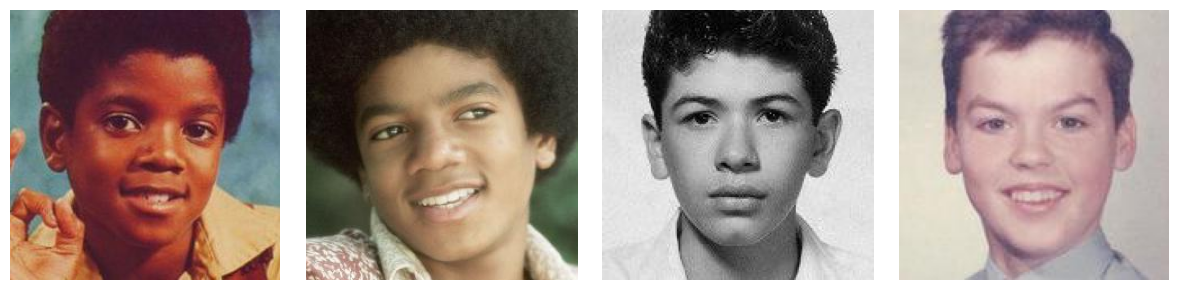

In [3]:
plot_images_from_folder('/kaggle/working/test_images', images_per_row=4, max_images=4)

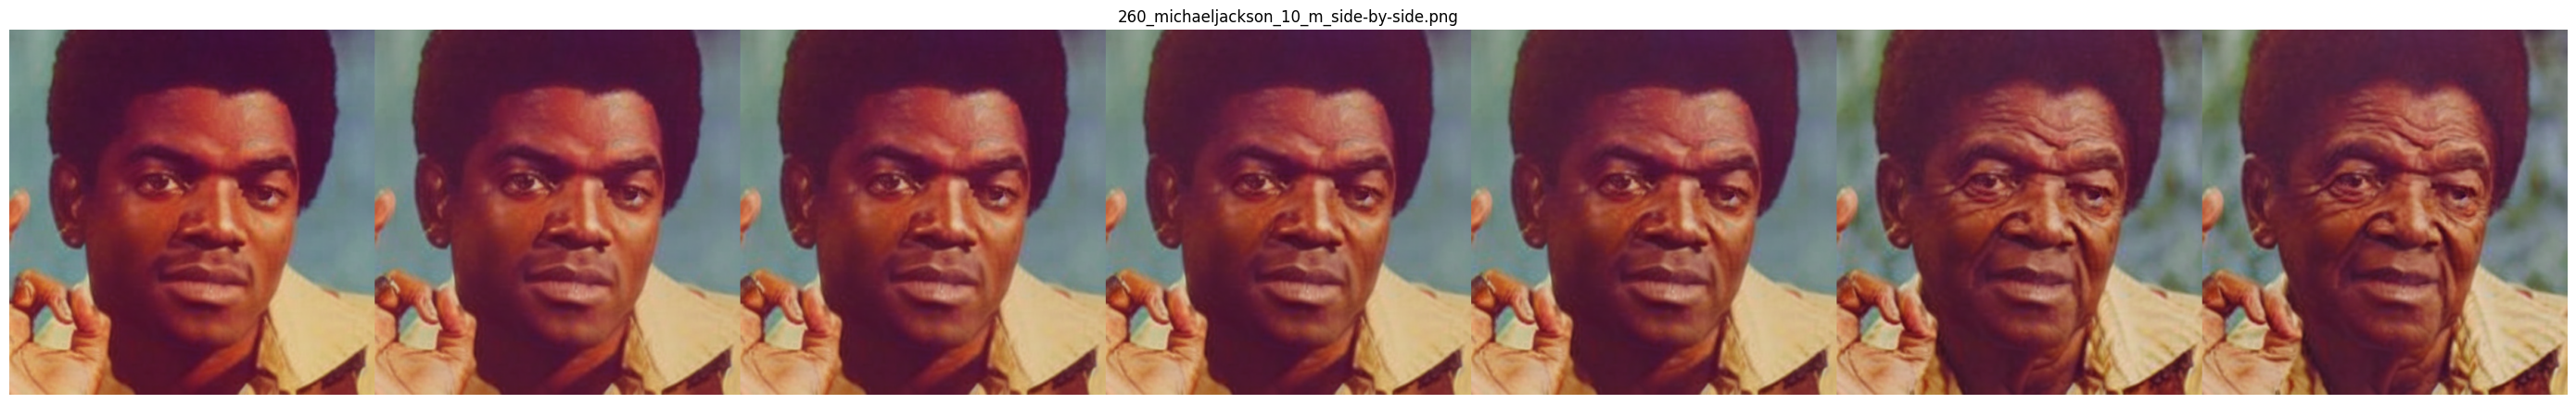

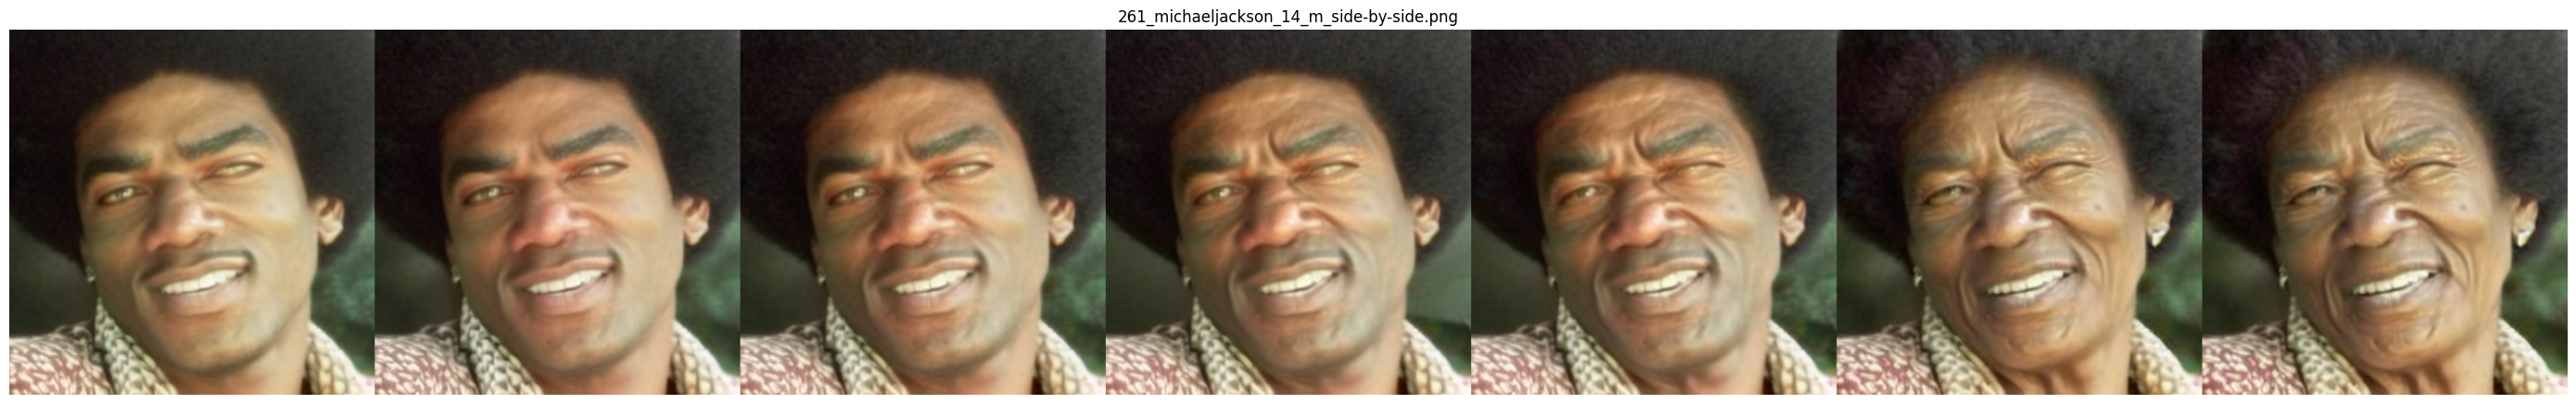

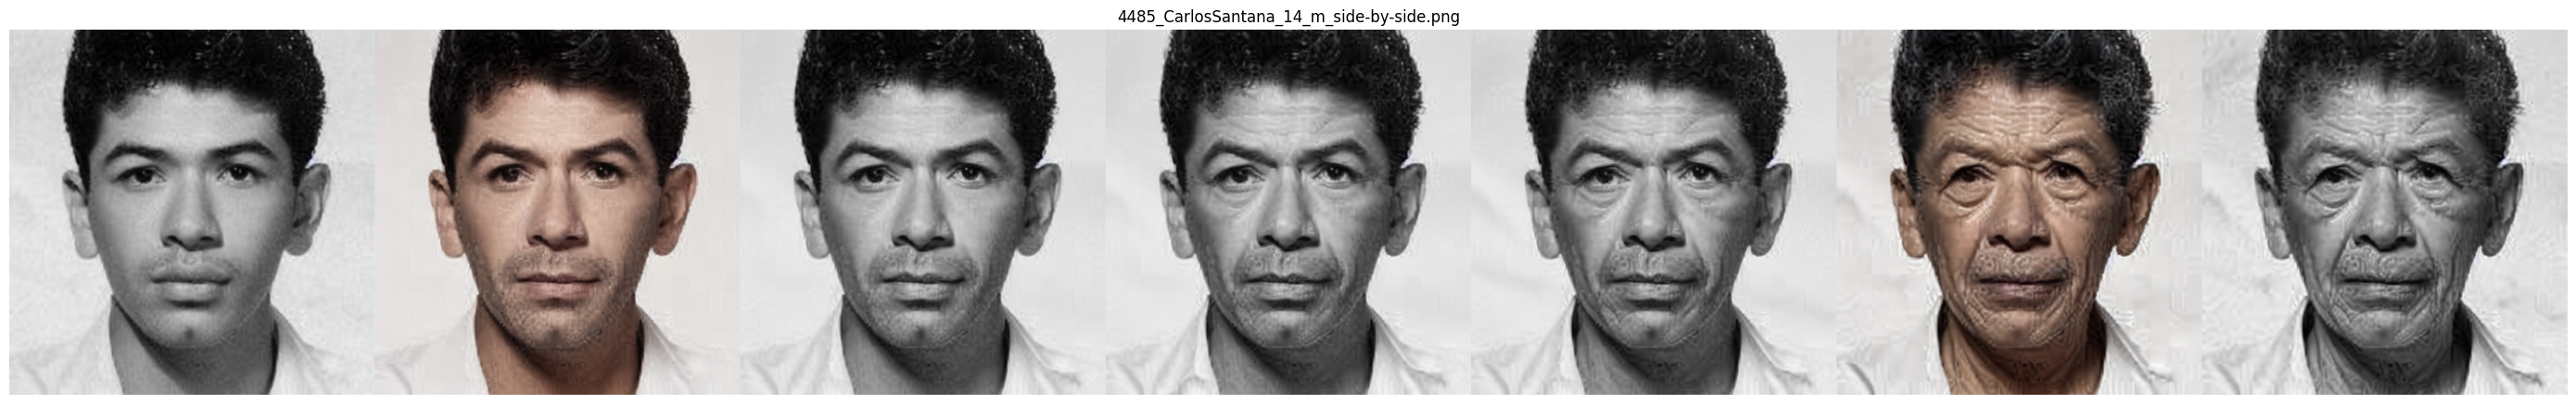

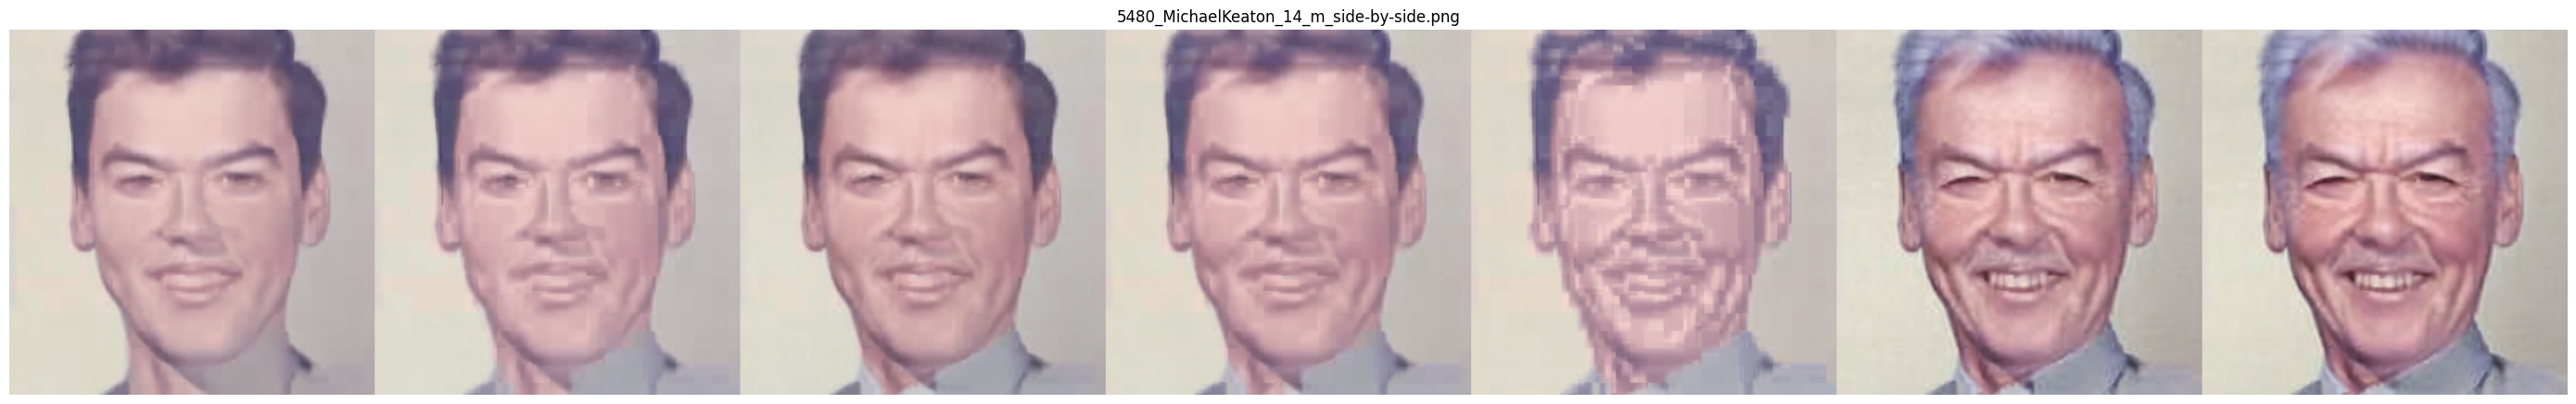

In [24]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Folder containing images
folder_path = '/kaggle/working/output/side-by-side'

# Get all PNG images
image_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
image_files.sort()  # optional

# Plot each image
for img_file in image_files:
    img_path = os.path.join(folder_path, img_file)
    img = Image.open(img_path)

    # Calculate figure size in inches to keep aspect ratio
    width_inch = img.width / 100  # scaling down for notebook
    height_inch = img.height / 100

    plt.figure(figsize=(width_inch, height_inch))
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_file, fontsize=12)
    plt.show()
